# Analysis for the unconditional generation

In [1]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandarallel import pandarallel
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from matplotlib import pyplot as plt
from rich.progress import track
from plotly import express as px
from rdkit.Chem.rdmolfiles import MolFromSmiles, MolFromMolBlock
from tqdm import tqdm

In [2]:
pandarallel.initialize(progress_bar=False)

INFO: Pandarallel will run on 14 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [3]:
from tools import count_novel_elements, count_unique_elements, count_unique_novel_elements

## Load data

In [4]:
dtypes = {
    "loads": "boolean",
    "errorfree": "boolean",
    "sanitizes": "boolean",
    "connected": "boolean",
    "all_hydrogens": "boolean",
    "no_radicals": "boolean",
    "chemical": "boolean",
    "physical": "boolean",
    "fail": "boolean",
}

In [5]:
dfs = {}
results = {
    "EQGAT-diff": "data/03_evaluation/eqgat_100000_predictions.csv",
    "FlowMol": "data/03_evaluation/flowmol_100000_predictions.csv",
    "GCDM": "data/03_evaluation/gcdm_100000_predictions.csv",
    "GeoLDM": "data/03_evaluation/geoldm_100000_predictions.csv",
    "SemlaFlow": "data/03_evaluation/semlaflow_100000_predictions.csv",
}
results_desc = {
    # "EQGAT-diff": "data/04_description/eqgat_100000_predictions_desc.csv",
    # "FlowMol": "data/04_description/flowmol_100000_predictions_desc.csv",
    # "GCDM": "data/04_description/gcdm_100000_predictions_desc.csv",
    # "GeoLDM": "data/04_description/geoldm_100000_predictions_desc.csv",
    # "SemlaFlow": "data/04_description/semlaflow_100000_predictions_desc.csv",
}
results_pp = {
    "EQGAT-diff + PP": "data/03_evaluation/eqgat_100000_predictions_pp.csv",
    "FlowMol + PP": "data/03_evaluation/flowmol_100000_predictions_pp.csv",
    "GCDM + PP": "data/03_evaluation/gcdm_100000_predictions_pp.csv",
    "GeoLDM + PP": "data/03_evaluation/geoldm_100000_predictions_pp.csv",
    "SemlaFlow + PP": "data/03_evaluation/semlaflow_100000_predictions_pp.csv",
}
results_pp_desc = {
    # "EQGAT-diff + PP": "data/04_description/eqgat_100000_predictions_pp_desc.csv",
    # "FlowMol + PP": "data/04_description/flowmol_100000_predictions_pp_desc.csv",
    # "GCDM + PP": "data/04_description/gcdm_100000_predictions_pp_desc.csv",
    # "GeoLDM + PP": "data/04_description/geoldm_100000_predictions_pp_desc.csv",
    # "SemlaFlow + PP": "data/04_description/semlaflow_100000_predictions_pp_desc.csv",
}
datasets = {
    # "DrugBank": "data/03_evaluation/drugbank_approved_2d.csv",
    "DrugBank": "data/03_evaluation/drugbank_approved_3d.csv",
    "GEOM Drugs": "data/03_evaluation/geom_drugs.csv",
}
dataset_desc = {
    # "DrugBank": "data/04_description/drugbank_approved_2d_desc.csv",
    # "DrugBank": "data/04_description/drugbank_approved_3d_desc.csv",
    # "GEOM Drugs": "data/04_description/geom_drugs_desc.csv",
}
for name, file in track((results_desc | results | results_pp_desc | results_pp | dataset_desc | datasets).items()):
    df = pd.read_csv(file, low_memory=False, dtype=dtypes)
    df["method"] = name
    if "fail" not in df:
        df["fail"] = False
    else:
        df["fail"] = df["fail"].fillna(False)
    dfs[name] = df
df = pd.concat(dfs.values()).reset_index(drop=True)

Output()

In [6]:
df.method.unique()

array(['EQGAT-diff', 'FlowMol', 'GCDM', 'GeoLDM', 'SemlaFlow',
       'EQGAT-diff + PP', 'FlowMol + PP', 'GCDM + PP', 'GeoLDM + PP',
       'SemlaFlow + PP', 'DrugBank', 'GEOM Drugs'], dtype=object)

In [7]:
# define order of methods
order = [
    # "GEOM Drugs Validation",
    # "GEOM Drugs Testing",
    "EQGAT-diff",
    "FlowMol",
    "GCDM",
    "GeoLDM",
    "SemlaFlow",
    "EQGAT-diff + PP",
    "FlowMol + PP",
    "GCDM + PP",
    "GeoLDM + PP",
    "SemlaFlow + PP",
    "GEOM Drugs",
    # "GEOM Drugs training data",
    "DrugBank",
    # "DrugBank Approved",
]
df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)

In [8]:
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

connected: boolean
chemical: boolean
physical: boolean
ensemble_avg_energy: float64
mol_pred_energy: float64
energy_ratio: float64
passes_valence_checks: object
passes_kekulization: object
number_bonds: float64
shortest_bond_relative_length: float64
longest_bond_relative_length: float64
number_short_outlier_bonds: float64
number_long_outlier_bonds: float64
number_angles: float64
most_extreme_relative_angle: float64
number_outlier_angles: float64
number_noncov_pairs: float64
shortest_noncovalent_relative_distance: float64
number_clashes: float64
number_valid_bonds: float64
number_valid_angles: float64
number_valid_noncov_pairs: float64
number_aromatic_rings_checked: float64
number_aromatic_rings_pass: float64
aromatic_ring_maximum_distance_from_plane: float64
number_double_bonds_checked: float64
number_double_bonds_pass: float64
double_bond_maximum_distance_from_plane: float64
all_atoms_connected: object
mol_pred_loaded: object
sanitization: object
bond_lengths: object
bond_angles: obje

In [9]:
# reference smiles
reference = "GEOM Drugs"
df_ref = dfs[reference]
reference_smiles = set(df_ref["smiles"].values)

In [10]:
df["total_number"] = True

# molecular graph checks
cols = ["loads", "sanitizes", "connected", "no_radicals", "all_hydrogens"]
df[cols] = df[cols].astype("boolean")  # .fillna(False)
df["all_hydrogens"] = df["all_hydrogens"] & df["no_radicals"].fillna(True)
cols = ["loads", "sanitizes", "connected", "all_hydrogens"]
df["chemical"] = df[cols].fillna(False).all(axis=1)

# molecular conformation checks
cols = ["bond_lengths", "bond_angles", "internal_steric_clash", "aromatic_ring_flatness", "double_bond_flatness", "internal_energy"]
# cols = []
df[cols] = df[cols].astype("boolean")  # .fillna(False)
df["physical"] = df[cols].fillna(False).all(axis=1)

# combined
cols = ["connected", "chemical", "physical"]
df["valid"] = df[cols].fillna(False).all(axis=1)

# novelty
df["novel"] = df["smiles"].map(lambda x: x not in reference_smiles)
df["valid_novel"] = df["valid"].fillna(False) & df["novel"].fillna(False)

# smiles
df.loc[df["smiles"].isna(), "smiles"] = pd.NA
df["valid_smiles"] = pd.NA
df.loc[df.valid, "valid_smiles"] = df.loc[df.valid, "smiles"]
df.loc[df.valid_smiles.isna(), "valid"] = False
assert df["valid_smiles"].notna().sum() == df["valid"].sum()

In [11]:
# energy
df["delta"] = df["mol_pred_energy"] - df["ensemble_avg_energy"]
df["delta_normalized"] = df["delta"] / df["ensemble_avg_energy"]

In [12]:
metrics = {
    "ensemble_avg_energy": "Ensemble Average Energy",
    "mol_pred_energy": "Molecular Prediction Energy",
    "energy_ratio": "Energy ratio",
    "delta": "Energy delta",
    "delta_normalized": "Energy delta (normalized)",
    "sa": "SAscore",
    "sa_normalized": "Synthetic accessability score (normalized)",
    "spacial": "Spacial score",
    "qed": "QED",
    "logp": "LogP",
    "lipinski": "Lipinski R5",
    "num_heavy": "Number of heavy atoms",
    "weight": "Molecular weight",
    "num_rings": "Number of rings",
    "num_torsions": "Number of rotatable bonds",
}

In [13]:
df

,connected,chemical,physical,ensemble_avg_energy,mol_pred_energy,energy_ratio,passes_valence_checks,passes_kekulization,number_bonds,shortest_bond_relative_length,...,method,fail,Unnamed: 0,total_number,valid,novel,valid_novel,valid_smiles,delta,delta_normalized
0,True,True,True,89.870216,141.947300,1.579470,True,True,33.0,0.961159,...,EQGAT-diff,False,NaN,True,True,True,True,COc1ccc(CNN2C(=O)c3cnc(Cl)c(N4CCOCC4)c3C2=O)cc1OC,52.077084,0.579470
1,True,False,True,45.860677,181.354221,3.954460,True,True,29.0,0.913322,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,135.493545,2.954460
2,True,True,True,56.169252,107.991731,1.922613,True,True,36.0,0.958480,...,EQGAT-diff,False,NaN,True,True,True,True,C[C@@H]1C(=O)N(c2ccccc2Cl)C(=O)O[C@H]1C(=O)CCC...,51.822479,0.922613
3,<NA>,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,NaN,NaN
4,False,False,True,80.599624,144.976841,1.798729,True,True,28.0,0.958325,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,64.377217,0.798729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213949,True,True,True,125.266179,146.033207,1.165783,True,True,25.0,0.969423,...,GEOM Drugs,False,1213948.0,True,True,False,False,c1csc(Cc2nc(-c3ccc(-n4cccc4)cc3)no2)c1,20.767028,0.165783
1213950,True,True,True,86.739390,103.252739,1.190379,True,True,17.0,0.972182,...,GEOM Drugs,False,1213949.0,True,True,False,False,c1csc(Cc2nc3ccccc3[nH]2)c1,16.513349,0.190379
1213951,True,True,True,98.316741,142.940843,1.453881,True,True,20.0,0.963181,...,GEOM Drugs,False,1213950.0,True,True,False,False,c1nc(COc2nsnc2N2CCOCC2)cs1,44.624102,0.453881
1213952,True,True,True,123.670346,146.723998,1.186412,True,True,18.0,0.964253,...,GEOM Drugs,False,1213951.0,True,True,False,False,c1nc2sc3c(c2c2nnnn12)CCC3,23.053652,0.186412


In [14]:
df.groupby("method").size()

/tmp/ipykernel_2971191/2119285949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("method").size()


method
EQGAT-diff          93261
FlowMol            100000
GCDM               100000
GeoLDM              83400
SemlaFlow           94926
EQGAT-diff + PP     87068
FlowMol + PP        87231
GCDM + PP           95486
GeoLDM + PP         73787
SemlaFlow + PP      94874
GEOM Drugs         301855
DrugBank             2066
dtype: int64

In [15]:
df.groupby("method")["valid"].sum()

/tmp/ipykernel_2971191/1917589182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("method")["valid"].sum()


method
EQGAT-diff          59696
FlowMol             59782
GCDM                  180
GeoLDM               2883
SemlaFlow           87523
EQGAT-diff + PP     84201
FlowMol + PP        84239
GCDM + PP           95188
GeoLDM + PP         69561
SemlaFlow + PP      93053
GEOM Drugs         284278
DrugBank             2042
Name: valid, dtype: Int64

## Check

In [16]:
df.groupby("method").size()

/tmp/ipykernel_2971191/2119285949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("method").size()


method
EQGAT-diff          93261
FlowMol            100000
GCDM               100000
GeoLDM              83400
SemlaFlow           94926
EQGAT-diff + PP     87068
FlowMol + PP        87231
GCDM + PP           95486
GeoLDM + PP         73787
SemlaFlow + PP      94874
GEOM Drugs         301855
DrugBank             2066
dtype: int64

In [17]:
df.head()

,connected,chemical,physical,ensemble_avg_energy,mol_pred_energy,energy_ratio,passes_valence_checks,passes_kekulization,number_bonds,shortest_bond_relative_length,...,method,fail,Unnamed: 0,total_number,valid,novel,valid_novel,valid_smiles,delta,delta_normalized
0,True,True,True,89.870216,141.947300,1.579470,True,True,33.0,0.961159,...,EQGAT-diff,False,NaN,True,True,True,True,COc1ccc(CNN2C(=O)c3cnc(Cl)c(N4CCOCC4)c3C2=O)cc1OC,52.077084,0.579470
1,True,False,True,45.860677,181.354221,3.954460,True,True,29.0,0.913322,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,135.493545,2.954460
2,True,True,True,56.169252,107.991731,1.922613,True,True,36.0,0.958480,...,EQGAT-diff,False,NaN,True,True,True,True,C[C@@H]1C(=O)N(c2ccccc2Cl)C(=O)O[C@H]1C(=O)CCC...,51.822479,0.922613
3,<NA>,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,NaN,NaN
4,False,False,True,80.599624,144.976841,1.798729,True,True,28.0,0.958325,...,EQGAT-diff,False,NaN,True,False,True,False,<NA>,64.377217,0.798729


## Tables

In [18]:
def wrap_envs(latex: str, envs: list[str] = ["center", "small", "sc"]) -> str:
    for env in envs:
        latex = latex.replace(r"\begin{tabular}", r"\begin{" + env + "}" + "\n" + r"\begin{tabular}")
        latex = latex.replace(r"\end{tabular}", r"\end{tabular}" + "\n" + r"\end{" + env + "}")
    return latex

In [19]:
def denominator(x):
    n = 100000

    if len(x) == 0:
        return float("nan")
    if len(x) > n:
        return len(x)
    if len(x) < n / 10:
        return len(x)

    return n


def mean(x):
    return np.sum(x) / denominator(x)


def std(x):
    return np.sqrt(np.sum((x - mean(x)) ** 2) / denominator(x))

### Validity, Uniqueness, and Novelty

In [20]:
n = 100000


df_filter = df
aggs = {
    # "Number": ("total_number", "sum"),
    # "Denominator": ("total_number", denominator),
    r"\unit{\percent}  Valid": ("valid", lambda x: sum(x) / denominator(x)),
    # r"\unit{\percent}  Unique": (
    #     "smiles",
    #     lambda x: count_unique_elements(x) / denominator(x),
    # ),
    #  r"\unit{\percent}  Novel": (
    #     "smiles",
    #     lambda x: count_novel_elements(x, reference_smiles )  / denominator(x),
    # ),
    # r"\unit{\percent}  Novel \&  Unique": (
    #     "smiles",
    #     lambda x: count_unique_novel_elements(x, reference_smiles ) / denominator(x),
    # ),
    # r"\unit{\percent}  Novel \&  Unique \& Valid": (
    #     "valid_smiles",
    #     lambda x: count_unique_novel_elements(x, reference_smiles )  / denominator(x),
    # ),
    r"\unit{\percent}  Valid \&  Unique": (
        "valid_smiles",
        lambda x: count_unique_elements(x) / denominator(x),
    ),
    # r"\unit{\percent}  Valid \& Novel": (
    #     "valid_smiles",
    #     lambda x: compute_novelty(x, reference_smiles, total=1)  / denominator(x),
    # ),
    r"\unit{\percent}  Valid \& Unique \& Novel": (
        "valid_smiles",
        lambda x: count_unique_novel_elements(x, reference_smiles) / denominator(x),
    ),
}
df_agg = df_filter.groupby("method", observed=False).agg(**aggs)
cols = df_agg.columns
df_style = (
    df_agg.style.format("{:.1%}", subset=cols, escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:], escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:2]).format("{:.1%}", subset=cols[2:], escape="latex").format_index(escape="latex", axis=0)
)
df_style.index.name = None
df_style

,\unit{\percent} Valid,\unit{\percent} Valid \& Unique,\unit{\percent} Valid \& Unique \& Novel
EQGAT-diff,59.7%,59.7%,59.5%
FlowMol,59.8%,59.8%,59.7%
GCDM,0.2%,0.2%,0.2%
GeoLDM,2.9%,2.9%,2.9%
SemlaFlow,87.5%,87.4%,87.0%
EQGAT-diff + PP,84.2%,84.2%,84.0%
FlowMol + PP,84.2%,84.2%,84.1%
GCDM + PP,95.2%,95.2%,95.2%
GeoLDM + PP,69.6%,69.3%,69.3%
SemlaFlow + PP,93.1%,92.9%,92.4%


In [ ]:
caption = """
Validity, uniqueness, and novelty of 100,000 unconditionally generated molecules.
The table contains the percentages of successfully generated molecules that are valid, valid and unique, and valid, unique, and novel, out of the total number generated or contained in the data set.
All methods generated large numbers of valid, unique, and novel molecules, for example, SemlaFlow generated 87 thousand without post-processing and GCDM generated 95 thousand with post-processing.
Note that novelty is measured relative to GEOM Drugs, so GEOM Drugs itself does not contain any novel molecules and we can infer that about half of the molecules in DrugBank are present in GEOM Drugs.
"""
label = "tab:valid_unique_novel"
cols_def = "l" + "S[table-format=7.0]" * 0 + "S[table-format=3.1]" * 3
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table",
    hrules=True,
    caption=caption,
    column_format=cols_def,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
latex = latex.replace("\nGEOM", "\n" r"\midrule" "\n" "GEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
with open("tables/valid_unique_novel.tex", "w") as f:
    f.write(latex)

### Validity

In [ ]:
aggs = {
    # "Number": ("total_number", "sum"),
    # "Denominator": ("total_number", denominator),
    # r"\unit{\percent} Generated": ("total_number", mean),
    # r"\unit{\percent} Connected": ("connected", mean),
    r"\unit{\percent} Chemical": ("chemical", mean),
    r"\unit{\percent} Physical": ("physical", mean),
    r"\unit{\percent} Valid": ("valid", mean),
}
df_agg = df.groupby("method", observed=False).agg(**aggs)
cols = df_agg.columns
# df_agg.iloc[-3, 1] = pd.NA
# df_agg.iloc[-2, 2] = pd.NA
# df_agg.iloc[-1, 2] = pd.NA
df_style = (
    df_agg.style.format("{:.1%}", subset=cols, escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:], escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:2]).format("{:.1%}", subset=cols[2:], escape="latex").format_index(escape="latex", axis=0)
)
df_style.index.name = None
df_style

In [ ]:
caption = """
Validity of the generated and ground truth molecules.
The table contains the total number of molecules that was to be generated or is contained in the data set and the proportions of molecules that pass all the chemical validity test, all physical validity tests.
The last columns is the percentage of molecules that pass all the tests together.
"""
label = "tab:validity_split"
cols_def = "l" + "S[table-format=6.0]" * 0 + "S[table-format=3.1]" * 2 + "|S[table-format=3.1]"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table",
    hrules=True,
    caption=caption,
    column_format=cols_def,
)
latex = latex.replace("%", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
latex = latex.replace("GEOM", r"\midrule" "\nGEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
with open("tables/validity_split.tex", "w") as f:
    f.write(latex)

### Physical details

In [ ]:
aggs = {
    # "Number": ("total_number", "sum"),
    # "Denominator": ("total_number", denominator),
    # r"\unit{\percent} Generated": ("total_number", mean),
    # "Total number": ("total_number", "sum"),
    # r"\unit{\percent} InChI": ("inchi_convertible", mean),
    r"Bond lengths": ("bond_lengths", mean),
    r"Bond angles": ("bond_angles", mean),
    r"Internal steric clash": ("internal_steric_clash", mean),
    r"Aromatic ring flatness": ("aromatic_ring_flatness", mean),
    r"Double bond flatness": ("double_bond_flatness", mean),
    r"Internal energy": ("internal_energy", mean),
    r"\unit{\percent} Physical": ("physical", mean),
}
df_agg = df.groupby("method", observed=False).agg(**aggs)
cols = df_agg.columns
df_style = (
    df_agg.style.format("{:.1%}", subset=cols, escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:], escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:2]).format("{:.1%}", subset=cols[2:], escape="latex").format_index(escape="latex", axis=0)
)
df_style.index.name = None
df_style

In [ ]:
caption = """
Components of the physical validity of the generated and ground truth molecules.
The numbers shown are the percentages of the molecules that pass each of the intramolecular PoseBusters tests.
The last column is the percentage of molecules that pass all of the intramolecular tests.
The physical tests check the 3D conformations of the generated molecules.
"""
label = "tab:physical_validity"
cols_def = "l" + "S[table-format=7.0]" * 0 + "S[table-format=3.1]" * 6 + "|S[table-format=3.1]"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table",
    hrules=True,
    caption=caption,
    column_format=cols_def,
)
latex = latex.replace("%", "").replace("nan", "")
# latex = wrap_envs(latex, ["center"])
latex = latex.replace("GEOM", r"\midrule" "\nGEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
col1 = r"{Bond lengths} & {Bond angles} & {Internal steric clash} & {Aromatic ring flatness} & {Double bond flatness} & {Internal energy} & {\unit{\percent} Physical} \\"
col2 = (
    r"{}        & {}        & {Internal}        & {Planar}   & {Planar} & { }  & {}      \\"
    "\n"
    r"{}        & {Bond}    & {Bond}   & {steric}   & {aromatic} & {double} & {Internal} & { } \\"
    "\n"
    r"{}        & {lengths} & {angles} & {clash}    & {rings}    & {bonds}  & {energy}   & {\unit{\percent} Physical} \\"
)
latex = latex.replace(col1, col2)
with open("tables/physical_validity.tex", "w") as f:
    f.write(latex)

### Chemical details

In [ ]:
# ["loads", "sanitizes", "connected", "no_radicals", "all_hydrogens"]
aggs = {
    # "Number": ("total_number", "sum"),
    # "Denominator": ("total_number", denominator),
    # "Generated": ("total_number", mean),
    # r"\unit{\percent} InChI": ("inchi_convertible", mean),
    # r"File read": ("mol_pred_loaded", mean),
    r"Sanitizes": ("sanitizes", mean),
    r"Hydrogens explicit": ("all_hydrogens", mean),
    # r"No radicals": ("no_radicals", mean),
    r"Connected": ("connected", mean),
    # r"InChI convertible": ("inchi_convertible", mean),
    r"\unit{\percent} Chemical": ("chemical", mean),
}
df_agg = df.groupby("method", observed=False).agg(**aggs)
cols = df_agg.columns
df_style = (
    df_agg.style.format("{:.1%}", subset=cols, escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:1]).format("{:.1%}", subset=cols[1:], escape="latex").format_index(escape="latex", axis=0)
    # df_agg.style.format("{:.0f}", subset=cols[:2]).format("{:.1%}", subset=cols[2:], escape="latex").format_index(escape="latex", axis=0)
)
df_style.index.name = None
df_style

In [ ]:
caption = """
Components of the chemical validity of the generated and ground truth molecules. The numbers shown are the
percentages of the molecules that pass each of the tests. The last column is the percentage of
molecules that pass all of the tests.
The chemical tests check the molecular graph generated and they do not check the molecules' 3D conformations.
"""
label = "tab:chemical_validity"
cols_def = "l" + "S[table-format=7]" * 0 + "S[table-format=3.1]" * 3 + "|S[table-format=3.1]"
latex = df_style.to_latex(label=label, siunitx=True, environment="table", hrules=True, caption=caption, column_format=cols_def)
latex = latex.replace("%", "").replace("nan", "")
# latex = wrap_envs(latex, ["center"])
latex = latex.replace("GEOM", r"\midrule" "\nGEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
with open("tables/chemical_validity.tex", "w") as f:
    f.write(latex)

### Properties of valid molecules

In [ ]:
def interquartile_range(s: pd.Series) -> float:
    s = sorted(s.dropna())
    n = len(s)
    if n == 0:
        return float("nan")
    q1 = s[n // 4]
    q3 = s[(3 * n) // 4]
    return q3 - q1


In [ ]:
# combine mean and std into one column
names = [
    "weight",
    "num_heavy",
    "num_rings",
    "logp",
    # "sa",
    # "qed",
    # "energy_ratio",
    # "lipinski",
    # "spacial",
]

# df_agg = df_filter.groupby("method", observed=False).agg({name: ["mean", "std"] for name in names})
df_agg = df_filter.groupby("method", observed=False).agg({name: ["median", interquartile_range] for name in names})
df_agg = df_agg[[name for name in names if name in df_agg.columns]]

columns = {}
for column in set(c[0] for c in df_agg.columns if c[0] in names):
    columns[metrics[column]] = df_agg[column].apply(lambda x: f"{x[0]:.2f}({x[1]:.2f})", axis=1)

df_style = pd.DataFrame(columns)
# df_style = df_style[[names[c] for c in df_style.columns]]
df_style = df_style.style.format_index(escape="latex", axis=1)
df_style.index.name = None
df_style

caption = """
Various molecular properties.
The table contains the QED, SA, energy ratio, weight, number of heavy atoms, number of rings, Lipinski rule of five, logP, and spacial metrics.
"""
label = "tab:properties"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table",
    hrules=True,
    caption=caption,
    column_format="l" + "S[table-format=3.2(5)]S[table-format=3.2(3)]S[table-format=3.2(3)]S[table-format=3.2(3)]",
)
latex = latex.replace("%", "").replace("nan(nan)", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
latex = latex.replace(r"\begin{center}", r"\begin{center}" + "\n" + "\sisetup{separate-uncertainty}")
latex = latex.replace("GEOM", r"\midrule" "\nGEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
with open("tables/properties_2.tex", "w") as f:
    f.write(latex)

In [ ]:
# combine mean and std into one column
names = [
    # "weight",
    # "num_heavy",
    # "num_rings",
    # "logp",
    "qed",
    "sa",
    "lipinski",
    "spacial",
    # "energy_ratio",
]


# df_agg = df_filter.groupby("method", observed=False).agg({name: ["mean", "std"] for name in names})
df_agg = df_filter.groupby("method", observed=False).agg({name: ["median", interquartile_range] for name in names})
df_agg = df_agg[[name for name in names if name in df_agg.columns]]

columns = {}
for column in set(c[0] for c in df_agg.columns if c[0] in names):
    columns[metrics[column]] = df_agg[column].apply(lambda x: f"{x[0]:.2f}({x[1]:.2f})", axis=1)
df_style = pd.DataFrame(columns)
# df_style = df_style[[names[c] for c in df_style.columns]]
df_style = df_style.style.format_index(escape="latex", axis=1)
df_style.index.name = None

caption = """
Various molecular properties.
The table contains the QED, SA, energy ratio, weight, number of heavy atoms, number of rings, Lipinski rule of five, logP, and spacial metrics.
"""
label = "tab:properties"
latex = df_style.to_latex(
    label=label,
    siunitx=True,
    environment="table",
    hrules=True,
    caption=caption,
    column_format="l" + "S[table-format=3.2(3)]S[table-format=3.2(3)]S[table-format=3.2(4)]S[table-format=3.2(3)]S[table-format=3.2(4)]",
)
latex = latex.replace("%", "").replace("nan(nan)", "").replace("nan", "")
latex = wrap_envs(latex, ["center"])
latex = latex.replace(r"\begin{center}", r"\begin{center}" + "\n" + r"\sisetup{separate-uncertainty}")
latex = latex.replace("GEOM", r"\midrule" "\nGEOM")
latex = latex.replace("EQGAT-diff + PP", r"\midrule" "\nEQGAT-diff + PP")
with open("tables/properties_1.tex", "w") as f:
    f.write(latex)

### Energy ratio

In [ ]:
def interquartile_range(s: pd.Series) -> float:
    s = sorted(s.dropna())
    n = len(s)
    if n == 0:
        return float("nan")
    q1 = s[n // 4]
    q3 = s[(3 * n) // 4]
    return q3 - q1


# df_filter = df[df.valid]
df_filter = df
aggs = {
    # "ensemble_avg_energy": ["mean", "std"],
    # "mol_pred_energy": ["mean", "std"],
    # "energy_ratio": ["mean", "std"],
    "ensemble_avg_energy": ["median", interquartile_range],
    "mol_pred_energy": ["median", interquartile_range],
    "energy_ratio": ["median", interquartile_range],
}
df_agg = df_filter.groupby("method", observed=False).agg(aggs)
cols = df_agg.columns
# df_style = df_agg.style.format("{:.2f}", subset=cols).format_index(
#     escape="latex", axis=1
# )
df_style = df_agg
df_style.index.name = None
df_style

In [ ]:
# caption = """
# Energy ratio.
# The table contains the ensemble average energy, the predicted energy, and the energy ratio.
# """
# label = "tab:unconditional_energy"
# latex = df_style.to_latex(
#     label=label, siunitx=True, environment="table*", hrules=True, caption=caption
# )
# latex = latex.replace("%", "").replace("nan", "")
# with open("tables/unconditional_energy.tex", "w") as f:
#     f.write(latex)

## Plots

In [ ]:
# define order of methods
order_data = [
    "DrugBank",
    "GEOM Drugs",
]
order_methods = [
    # "EQGAT-diff",
    # "FlowMol",
    # "GCDM",
    # "GeoLDM",
    # "SemlaFlow",
    "EQGAT + PP",
    "EQGAT + PP",
    "GCDM-SBDD + PP",
    "GeoLDM + PP",
    "SemlaFlow + PP",
]

In [ ]:
def make_histplot(df, metric, **kwargs):
    # sns.histplot(
    #     df[(df.valid) & (df.method.isin(order_methods + order_data))][["method", metric]].reset_index(drop=True),
    #     x=metric,
    #     hue="method",
    #     cumulative=False,
    #     common_norm=False,
    #     stat="density",
    #     element="step",
    #     hue_order=order_data + order_methods,
    #     linewidth=0.0,
    #     fill=False,
    #     **kwargs,
    #     # legend=True, palette="tab10", linewidth=1.5
    # )
    sns.kdeplot(
        df[(df.valid) & (df.method.isin(order_data))][["method", metric]].reset_index(drop=True),
        x=metric,
        hue="method",
        cumulative=False,
        common_norm=False,
        # stat="density",
        # element="step",
        # kde=True,
        hue_order=order_data,
        linewidth=1.5,
        fill=True,
        **kwargs,
        # legend=True, palette="tab10", linewidth=1.5
    )
    sns.kdeplot(
        df[(df.valid) & (df.method.isin(order_methods))][["method", metric]].reset_index(drop=True),
        x=metric,
        hue="method",
        cumulative=False,
        common_norm=False,
        # stat="density",
        # element="step",
        # kde=True,
        hue_order=order_data + order_methods,
        linewidth=1.5,
        fill=False,
        **kwargs,
        # legend=True, palette="tab10", linewidth=1.5
    )

### QED

In [ ]:
metric = "qed"
name = metrics[metric]
make_histplot(df, metric)  # , bins=50)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0, 1)
plt.savefig(f"plots/unconditional_{metric}.png")

### Synthetically accessibility

In [ ]:
metric = "sa"
name = metrics[metric]
make_histplot(df, metric)  # , bins=40)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0, 10)
plt.savefig(f"plots/unconditional_{metric}.png")

### Energy ratio

In [ ]:
metric = "energy_ratio"
name = metrics[metric]
make_histplot(df, metric, log_scale=True)  # , bins=50)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0.5, 150)
plt.savefig(f"plots/unconditional_{metric}.png")

In [ ]:
metric = "delta"
name = metrics[metric]
make_histplot(df, metric, log_scale=True)  # , bins=20)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0.1, 1e5)
plt.savefig(f"plots/unconditional_{metric}.png")

In [ ]:
metric = "delta_normalized"
name = metrics[metric]
make_histplot(df, metric, log_scale=True)  # , bins=20)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0.01, 1000)
plt.savefig(f"plots/unconditional_{metric}.png")

### Number of heavy atoms

In [ ]:
metric = "num_heavy"
name = metrics[metric]
make_histplot(df, metric)  # , bins=20)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0, 60)
plt.savefig(f"plots/unconditional_{metric}.png")

In [ ]:
metric = "spacial"
name = metrics[metric]
make_histplot(df, metric)  # , bins=20)
# plt.title(name)
plt.xlabel(name)
plt.xlim(0, 70)
plt.savefig(f"plots/unconditional_{metric}.png")

# SI

## Plots

In [ ]:
# metric = "logp"
# name = metrics[metric]
# make_histplot(df, metric)  # , bins=20)
# # plt.title(name)
# plt.xlabel(name)
# # plt.xlim(0, 60)
# plt.savefig(f"plots/unconditional_{metric}.png")

In [21]:
# metric = "weight"
# name = metrics[metric]
# make_histplot(df, metric)  # , bins=20)
# # plt.title(name)
# plt.xlabel(name)
# plt.xlim(0, 1000)
# plt.savefig(f"plots/unconditional_{metric}.png")

In [22]:
# metric = "lipinski"
# name = metrics[metric]
# make_histplot(df, metric)  # , bins=20)
# # plt.title(name)
# plt.xlabel(name)
# plt.xlim(0.1, 5.9)
# plt.savefig(f"plots/unconditional_{metric}.png")

In [23]:
# metric = "num_rings"
# name = metrics[metric]
# make_histplot(df, metric)  # , bins=20)
# # plt.title(name)
# plt.xlabel(name)
# plt.xlim(0.1, 14.9)
# plt.savefig(f"plots/unconditional_{metric}.png")

In [24]:
# metric = "num_torsions"
# name = metrics[metric]
# make_histplot(df, metric)  # , bins=20)
# # plt.title(name)
# plt.xlabel(name)
# plt.xlim(0.1, 14.9)
# plt.savefig(f"plots/unconditional_{metric}.png")

In [25]:
# # define order of methods
# order_data = [
#     "DrugBank",
#     "GEOM Drugs",
# ]
# order_methods = [
#     "EQGAT-diff",
#     "FlowMol",
#     "GCDM",
#     "GeoLDM",
#     "SemlaFlow",
#     # "EQGAT + PP",
#     # "SemlaFlow Optimized",
#     # "EQGAT Optimized",
#     # "GCDM-SBDD Optimized",
#     # "GeoLDM Optimized",
# ]

### Physical check details

In [26]:
df[df.method == "DrugBank"]

,connected,chemical,physical,ensemble_avg_energy,mol_pred_energy,energy_ratio,passes_valence_checks,passes_kekulization,number_bonds,shortest_bond_relative_length,...,method,fail,Unnamed: 0,total_number,valid,novel,valid_novel,valid_smiles,delta,delta_normalized
910033,True,True,True,28.671964,75.028878,2.616803,True,True,16.0,0.961555,...,DrugBank,False,NaN,True,True,False,False,Cc1ncc(COP(=O)(O)O)c(C=O)c1O,46.356914,1.616803
910034,True,True,True,78.241343,139.986832,1.789167,True,True,29.0,0.918286,...,DrugBank,False,NaN,True,True,True,True,C[S@@+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2c...,61.745489,0.789167
910035,True,True,True,2.852575,19.861485,6.962650,True,True,5.0,0.971693,...,DrugBank,False,NaN,True,True,False,False,CC(=O)C(=O)O,17.008909,5.962650
910036,True,True,True,17.727336,29.449339,1.661239,True,True,12.0,0.981151,...,DrugBank,False,NaN,True,True,True,True,N[C@@H](Cc1ccccc1)C(=O)O,11.722003,0.661239
910037,True,True,True,35.835702,52.669343,1.469745,True,True,17.0,0.980033,...,DrugBank,False,NaN,True,True,False,False,O=C(O)CCCC[C@@H]1SC[C@@H]2NC(=O)N[C@@H]21,16.833642,0.469745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912094,True,True,True,21.970186,38.224253,1.739824,True,True,12.0,0.988887,...,DrugBank,False,NaN,True,True,False,False,Cc1cc(O)c(C(C)C)cc1Cl,16.254067,0.739824
912095,True,True,True,47.416644,56.428597,1.190059,True,True,17.0,0.988969,...,DrugBank,False,NaN,True,True,False,False,O=C(Nc1ccccc1)c1ccccc1O,9.011953,0.190059
912096,True,True,True,82.224333,90.117561,1.095996,True,True,28.0,0.985805,...,DrugBank,False,NaN,True,True,True,True,CC(=O)[C@@]1(O)CC[C@H]2[C@@H]3C=C(C)C4=CC(=O)C...,7.893228,0.095996
912097,True,True,True,153.716780,217.858334,1.417271,True,True,53.0,0.978622,...,DrugBank,False,NaN,True,True,True,True,CCOC(=O)Oc1c(OC)cc(C(=O)O[C@@H]2C[C@@H]3CN4CCc...,64.141553,0.417271


In [27]:
# define order of methods
order_data = [
    "DrugBank",
    "GEOM Drugs",
]
order_methods = [
    "EQGAT-diff",
    "FlowMol",
    "GCDM",
    "GeoLDM",
    "SemlaFlow",
    # "EQGAT + PP",
    # "SemlaFlow Optimized",
    # "EQGAT Optimized",
    # "GCDM-SBDD Optimized",
    # "GeoLDM Optimized",
]

In [28]:
metric_names = {
    "shortest_noncovalent_relative_distance": "Shortest normalized non-covalent distance",
    "shortest_bond_relative_length": "Shortest bond normalized bond length",
    "longest_bond_relative_length": "Longest bond normalized bond length",
    "most_extreme_relative_angle": "Most extreme normalized bond angle",
    "energy_ratio": "Energy ratio",
}

In [29]:
def plot_violations(
    df,
    metric,
    figsize=(5, 10),
    **kwargs,
):
    dfx = df.copy()
    dfx = dfx[np.isfinite(dfx[metric])]
    dfx = dfx[dfx.method.isin(order_data + order_methods)]
    methods_present = [o for o in order_data + order_methods if o in set(dfx.method)]
    dfx["method"] = pd.Categorical(dfx["method"], categories=methods_present, ordered=True)
    df_plot = dfx.reset_index()

    f, ax = plt.subplots(figsize=figsize)

    sns.stripplot(
        df_plot,
        x=metric,
        y="method",
        hue="method",
        hue_order=order_data + order_methods,
        dodge=False,
        ax=ax,
        size=2,
        linewidth=0.1,
        alpha=1.0,
        jitter=0.02,
        **kwargs,
    )

    sns.boxplot(
        df_plot,
        x=metric,
        y="method",
        hue="method",
        hue_order=order_data + order_methods,
        showfliers=False,
        ax=ax,
        **kwargs,
        # boxprops=dict(alpha=0.5),
    )
    # for patch in ax.artists:
    #     fc = patch.get_facecolor()
    #     patch.set_facecolor(plt.colors.to_rgba(fc, 0.1))

    # for collection in plt.gca().collections:
    #     collection.set_facecolor([*collection.get_facecolor()[0][:3], 0.3])  # Set alpha to 0.3
    #     collection.set_edgecolor([*collection.get_edgecolor()[0][:3], 0.3])  # Set alpha to 1.0

    print(len(plt.gca().collections))

    # for collection in plt.gca().collections:
    #     collection.set_facecolor([*collection.get_facecolor()[0][:3], 0.3])  # Set alpha to 0.3
    #     collection.set_edgecolor([*collection.get_edgecolor()[0][:3], 1.0])  # Set alpha to 1.0

    # move strip plot down
    for i, artist in enumerate(ax.collections):
        artist.set_offsets(artist.get_offsets() + [0, 0.45])

    plt.xlabel(metric_names[metric])
    ax.set_ylabel("")

In [ ]:
metric = "shortest_noncovalent_relative_distance"
plot_violations(df, metric, figsize=(10, 6))
plt.axvline(x=0.75, color="red", linestyle="--", linewidth=1, zorder=0)
plt.axvspan(0.0, 0.75, color="red", alpha=0.05, zorder=0)
plt.xlim(0, 1.65)
plt.savefig(f"plots/{metric}.png", bbox_inches="tight")

In [ ]:
metric = "shortest_bond_relative_length"
plot_violations(df, metric, figsize=(10, 6))
plt.axvline(x=0.8, color="red", linestyle="--", linewidth=1, zorder=0)
plt.axvspan(0.0, 0.8, color="red", alpha=0.05, zorder=0)
plt.xlim(0.0, 1.2)
plt.savefig(f"plots/{metric}.png", bbox_inches="tight")

In [ ]:
metric = "longest_bond_relative_length"
plot_violations(df, metric, figsize=(10, 6))
plt.axvline(x=1.2, color="red", linestyle="--", linewidth=1, zorder=0)
plt.axvspan(1.2, 1.6, color="red", alpha=0.05, zorder=0)
plt.xlim(0.9, 1.6)
plt.savefig(f"plots/{metric}.png", bbox_inches="tight")

In [ ]:
metric = "most_extreme_relative_angle"
plot_violations(df, metric, figsize=(10, 6))
plt.axvline(x=1.2, color="red", linestyle="--", linewidth=1, zorder=0)
plt.axvspan(1.2, 2.0, color="red", alpha=0.05, zorder=0)
plt.xlim(0.9, 2.0)
plt.savefig(f"plots/{metric}.png", bbox_inches="tight")

In [ ]:
df[df.method == "DrugBank"].sort_values("energy_ratio")[["name"]]

In [ ]:
file = "/homes/buttensc/Network/Projects/3d_mol_gen_benchmark/data/01_raw/drugbank_approved_3d.sdf"
molblocks = dict(enumerate(open(file).read().strip().strip("$$$$\n").split("$$$$\n")))

In [ ]:
# MolFromMolBlock(molblocks[1553])
MolFromMolBlock(molblocks[1189])
MolFromMolBlock(molblocks[1622])
MolFromMolBlock(molblocks[1563])

# Double histogram plots

In [30]:
def count_total_number(smiles: str) -> int:
    if pd.isna(smiles):
        return pd.NA
    mol = MolFromSmiles(smiles)
    if mol is None:
        return pd.NA
    # mol = AddHs(mol)
    # get total number of atoms
    return mol.GetNumAtoms()


df["number_atoms"] = df["smiles"].parallel_apply(count_total_number)

[09:31:34] Explicit valence for atom # 20 P, 6, is greater than permitted
[09:31:34] Explicit valence for atom # 9 P, 7, is greater than permitted
[09:31:34] Explicit valence for atom # 25 S, 5, is greater than permitted
[09:31:35] Explicit valence for atom # 8 S, 5, is greater than permitted
[09:31:35] Explicit valence for atom # 8 S, 5, is greater than permitted
[09:31:35] Explicit valence for atom # 18 P, 7, is greater than permitted
[09:31:35] Explicit valence for atom # 10 S, 5, is greater than permitted
[09:31:36] Explicit valence for atom # 14 P, 7, is greater than permitted
[09:31:36] Explicit valence for atom # 2 P, 7, is greater than permitted
[09:31:36] Explicit valence for atom # 19 P, 7, is greater than permitted
[09:31:36] Explicit valence for atom # 6 P, 6, is greater than permitted
[09:31:36] Explicit valence for atom # 5 P, 7, is greater than permitted
[09:31:36] Explicit valence for atom # 11 S, 5, is greater than permitted
[09:31:36] Explicit valence for atom # 3 S, 

In [41]:
# define order of methods
order_data = [
    "DrugBank",
    "GEOM Drugs",
]
order_methods = [
    # "EQGAT-diff",
    # "FlowMol",
    # "GCDM",
    # "GeoLDM",
    # "SemlaFlow",
    "EQGAT-diff + PP",
    "FlowMol + PP",
    "GCDM + PP",
    "GeoLDM + PP",
    "SemlaFlow + PP",
]

In [42]:
metrics = {
    "delta_normalized": "Energy delta (normalized)",
    "delta": "Energy delta",
    "energy_ratio": "Energy ratio",
    "ensemble_avg_energy": "Ensemble Average Energy",
    "lipinski": "Lipinski rule of 5",
    "logp": "LogP",
    "mol_pred_energy": "Molecular Prediction Energy",
    "num_heavy": "Number of heavy atoms",
    "num_rings": "Number of rings",
    "num_torsions": "Number of rotatable bonds",
    "number_atoms": "Number of atoms",
    "qed": "Quantitative estimation of drug-likeness",
    "refractivity": "Refractivity",
    "sa_normalized": "Synthetic Accessability Score (normalized)",
    "sa": "Synthetic accessability score",
    "spacial": "Spacial score",
    "weight": "Molecular weight",
}

In [43]:
def make_double_hist(df, metric, xlims=None, figsize=(10, 5), check="valid", **kwargs):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, sharex=True)

    shared_kwargs = dict(x=metric, hue="method", cumulative=False, common_norm=False, legend=True)

    df_plot = df[(df[check]) & (df.method.isin(order_methods))][["method", metric]].reset_index(drop=True)
    ax = sns.kdeplot(ax=axes[0], data=df_plot, hue_order=order_data + order_methods, linewidth=2.0, fill=False, **shared_kwargs, **kwargs)
    df_plot = df[(df[check]) & (df.method.isin([order_data[0]]))][["method", metric]].reset_index(drop=True)
    ax = sns.kdeplot(ax=axes[0], data=df_plot, hue_order=order_data, linewidth=1.0, fill=True, **shared_kwargs, **kwargs)
    ax.legend(title=None, labels=list(reversed(order_methods)) + order_data[:1], reverse=True)

    df_plot = df[(df[check]) & (df.method.isin(order_methods))][["method", metric]].reset_index(drop=True)
    ax = sns.kdeplot(ax=axes[1], data=df_plot, hue_order=order_data + order_methods, linewidth=2.0, fill=False, **shared_kwargs, **kwargs)
    df_plot = df[(df[check]) & (df.method.isin([order_data[1]]))][["method", metric]].reset_index(drop=True)
    ax = sns.kdeplot(ax=axes[1], data=df_plot, hue_order=order_data, linewidth=1.0, fill=True, **shared_kwargs, **kwargs)
    ax.legend(title=None, labels=list(reversed(order_methods)) + order_data[1:], reverse=True)

    for i in range(2):
        axes[i].set_xlabel(metrics[metric])
        if xlims is not None:
            axes[i].set_xlim(xlims)
    fig.tight_layout()
    return fig, axes

In [44]:
def make_double_bar(df, metric, xlims=None, figsize=(10, 5), check="valid", **kwargs):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, sharex=True)

    shared_kwargs = dict(x=metric, hue="method", cumulative=False, common_norm=False, legend=True)

    df_plot = df[(df[check]) & (df.method.isin(order_methods))][["method", metric]].reset_index(drop=True)
    ax = sns.histplot(ax=axes[0], data=df_plot, hue_order=order_data + order_methods, linewidth=2.0, fill=False, **shared_kwargs, **kwargs)
    df_plot = df[(df[check]) & (df.method.isin([order_data[0]]))][["method", metric]].reset_index(drop=True)
    ax = sns.histplot(ax=axes[0], data=df_plot, hue_order=order_data, linewidth=1.0, fill=True, **shared_kwargs, **kwargs)
    ax.legend(title=None, labels=list(reversed(order_methods)) + order_data[:1], reverse=True)

    df_plot = df[(df[check]) & (df.method.isin(order_methods))][["method", metric]].reset_index(drop=True)
    ax = sns.histplot(ax=axes[1], data=df_plot, hue_order=order_data + order_methods, linewidth=2.0, fill=False, **shared_kwargs, **kwargs)
    df_plot = df[(df[check]) & (df.method.isin([order_data[1]]))][["method", metric]].reset_index(drop=True)
    ax = sns.histplot(ax=axes[1], data=df_plot, hue_order=order_data, linewidth=1.0, fill=True, **shared_kwargs, **kwargs)
    ax.legend(title=None, labels=list(reversed(order_methods)) + order_data[1:], reverse=True)

    for i in range(2):
        axes[i].set_xlabel(metrics[metric])
        if xlims is not None:
            axes[i].set_xlim(xlims)
    fig.tight_layout()
    return fig, axes

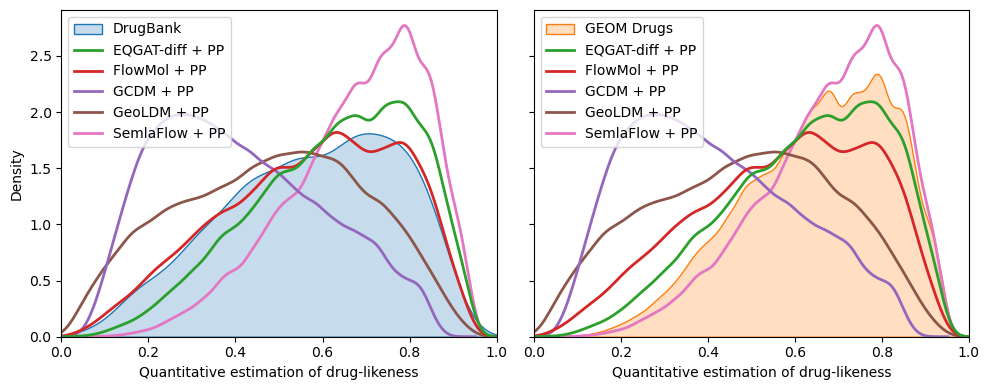

In [45]:
metric = "qed"
fig, axes = make_double_hist(df, metric, xlims=(0.0, 1.0), figsize=(10, 4.0), check="valid")
# fig.savefig(f"plots/{metric}.png")

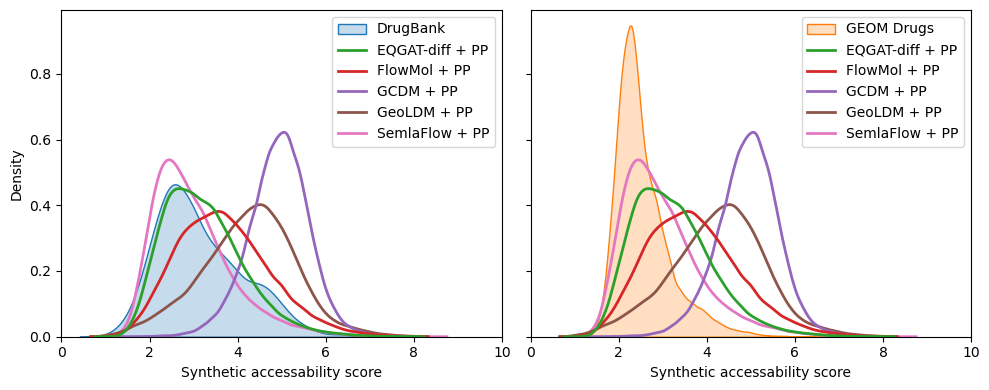

In [46]:
metric = "sa"
fig, axes = make_double_hist(df, metric, xlims=(0.0, 10.0), figsize=(10, 4.0), check="valid")
# fig.savefig(f"plots/{metric}.png")

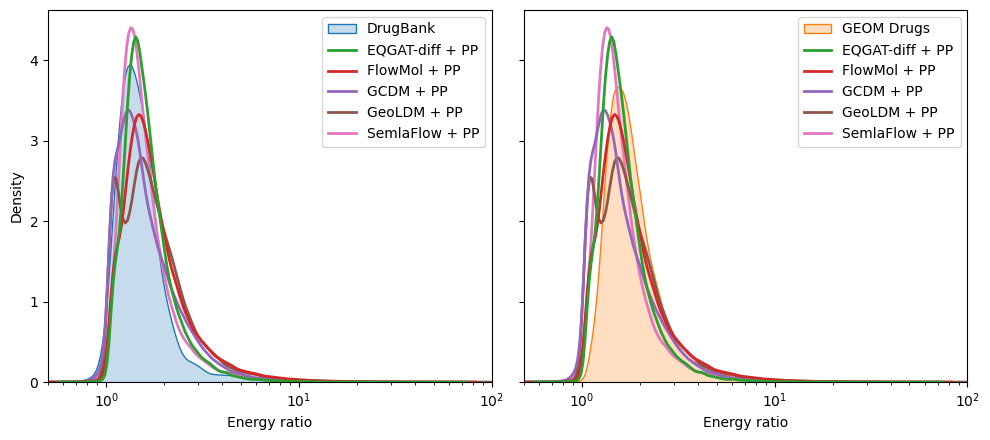

In [47]:
metric = "energy_ratio"
fig, axes = make_double_hist(df, metric, xlims=(0.5, 100.0), log_scale=True, figsize=(10, 4.5), check="valid")
# fig.savefig(f"plots/{metric}.png")

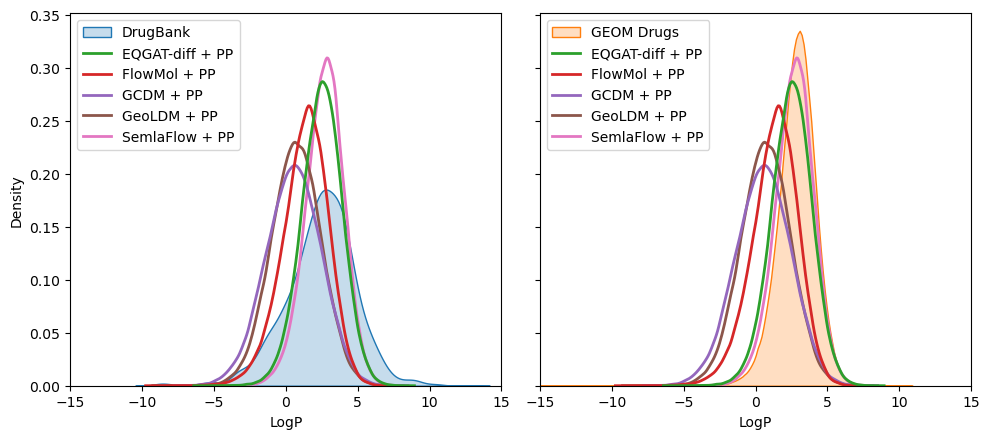

In [48]:
metric = "logp"
fig, axes = make_double_hist(df, metric, xlims=(-15, 15), log_scale=False, figsize=(10, 4.5), check="valid")
# for ax in axes:
#     ax.axvline(x=-0.4, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvline(x=5.6, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvspan(-0.4, 5.6, color="gray", alpha=0.05, zorder=-10)
# fig.savefig(f"plots/{metric}.png")

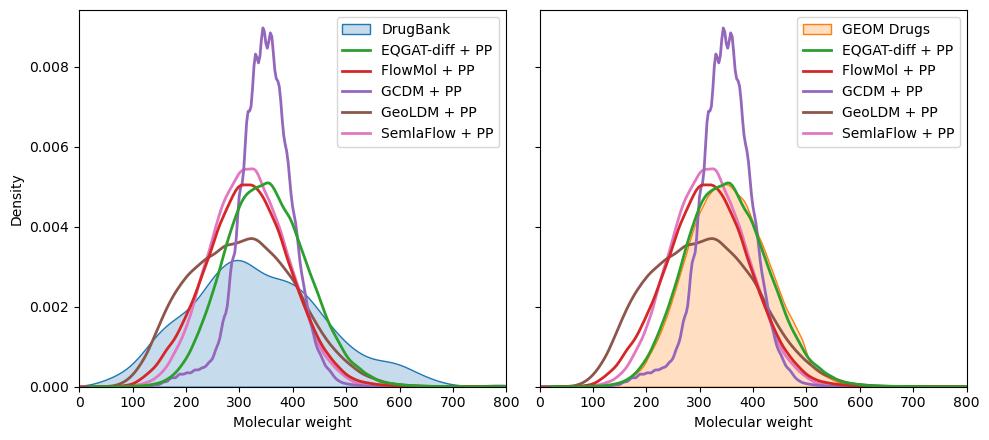

In [49]:
metric = "weight"
fig, axes = make_double_hist(df, metric, xlims=(0, 800), log_scale=False, figsize=(10, 4.5), check="valid")
# for ax in axes:
#     ax.axvline(x=160, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvline(x=480, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvspan(160, 480, color="gray", alpha=0.05, zorder=-10)
# fig.savefig(f"plots/{metric}.png")

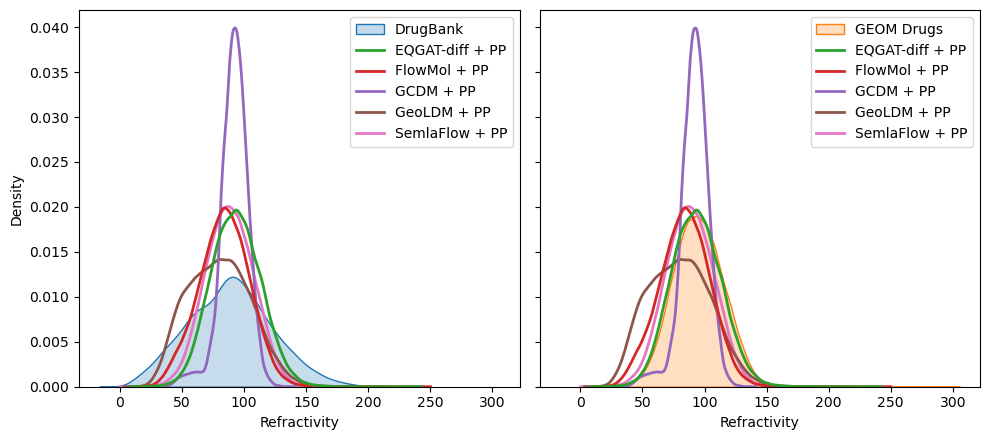

In [50]:
metric = "refractivity"
fig, axes = make_double_hist(df, metric, log_scale=False, figsize=(10, 4.5), check="valid")
# for ax in axes:
#     ax.axvline(x=40, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvline(x=130, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvspan(40, 130, color="gray", alpha=0.05, zorder=-10)
# fig.savefig(f"plots/{metric}.png")

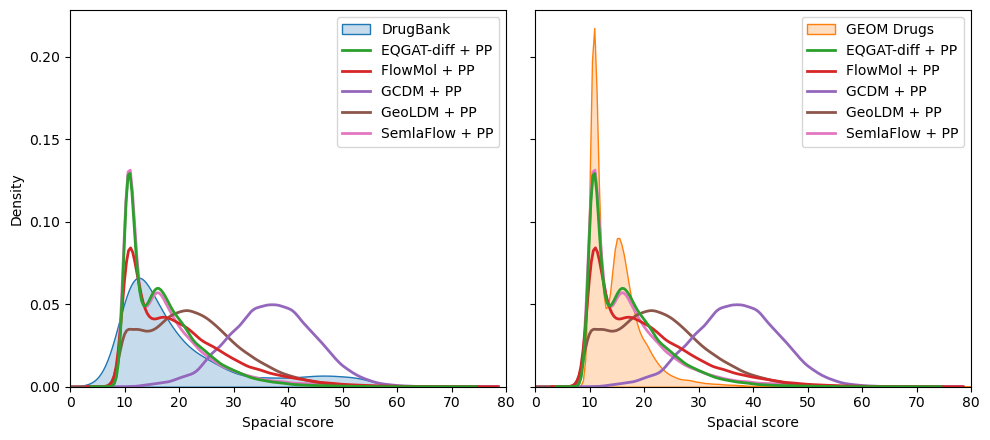

In [51]:
metric = "spacial"
fig, axes = make_double_hist(df, metric, xlims=(0, 80), log_scale=False, figsize=(10, 4.5), check="valid")
# fig.savefig(f"plots/{metric}.png")

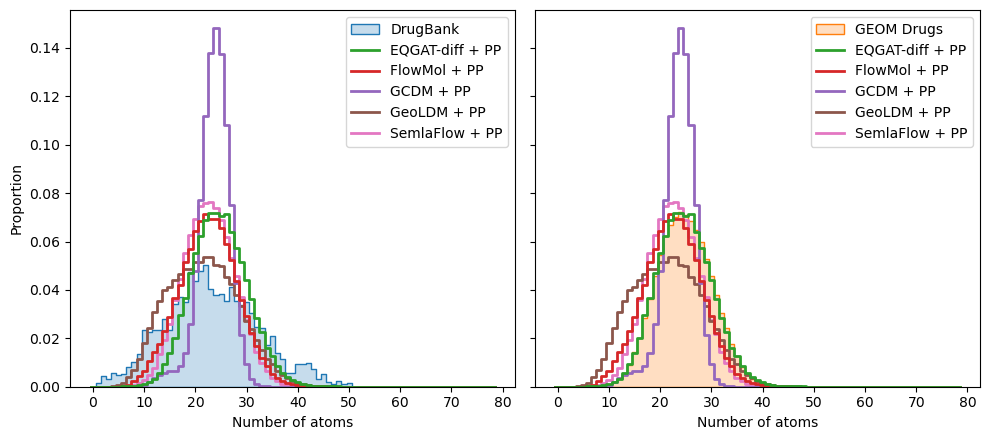

In [52]:
metric = "number_atoms"
fig, axes = make_double_bar(
    df,
    metric,
    bins=[-0.5 + i for i in range(80)],
    element="step",
    stat="proportion",
    figsize=(10, 4.5),
    # check="valid",
    check="sanitizes",
)
# for ax in axes:
#     ax.axvline(x=20, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvline(x=70, color="gray", linestyle="--", linewidth=1, zorder=-10)
#     ax.axvspan(20, 70, color="gray", alpha=0.05, zorder=-10)
# fig.savefig(f"plots/{metric}.png")

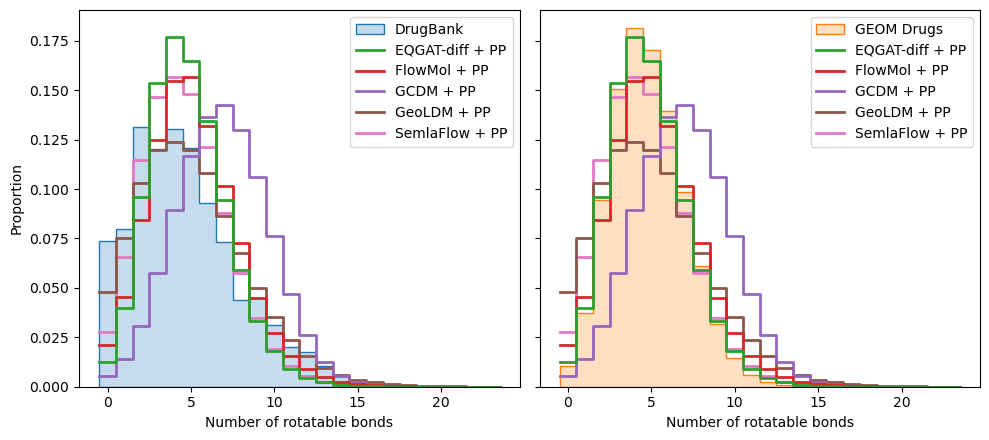

In [53]:
metric = "num_torsions"
fig, axes = make_double_bar(
    df,
    metric,
    bins=[-0.5 + i for i in range(25)],
    element="step",
    stat="proportion",
    figsize=(10, 4.5),
    # check="valid",
    check="sanitizes",
)
# fig.savefig(f"plots/{metric}.png")

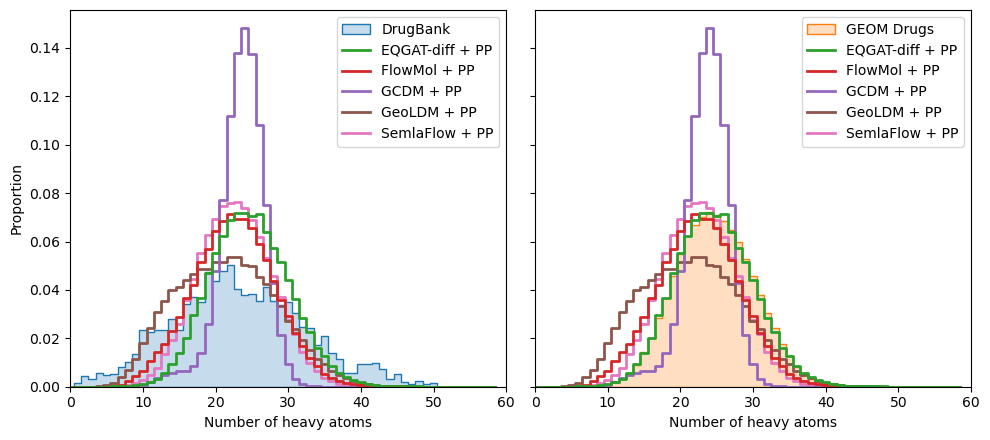

In [54]:
metric = "num_heavy"
fig, axes = make_double_bar(
    df,
    metric,
    bins=[-0.5 + i for i in range(60)],
    element="step",
    stat="proportion",
    xlims=(0, 60),
    figsize=(10, 4.5),
    check="sanitizes",
    # check="valid",
)
# fig.savefig(f"plots/{metric}.png")

In [ ]:
from rdkit.Chem.Descriptors import MolWt, NumRadicalElectrons, ExactMolWt, HeavyAtomMolWt
from rdkit.Chem.rdmolfiles import MolFromSmiles
from rdkit.Chem.rdmolops import AddHs


def calc_weight(smiles) -> float:
    if pd.isna(smiles):
        return float("nan")
    mol = MolFromSmiles(smiles)
    mol = AddHs(mol)
    if mol is None:
        return float("nan")
    # weight = MolWt(mol)
    weight = HeavyAtomMolWt(mol)
    return float(weight)


df["weight"] = df["smiles"].parallel_apply(calc_weight)